In [83]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from pydantic import SecretStr,BaseModel , Field 
from typing import TypedDict,NotRequired,Annotated, Literal
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
import operator

from dotenv import load_dotenv

load_dotenv()

True

In [84]:
llm_generator = ChatGoogleGenerativeAI(
    model = "gemini-3.5-flash-lite",
    api_key = SecretStr(os.environ["GOOGLE_API_KEY"]),
)

In [85]:
llm_evaluator = ChatGoogleGenerativeAI(
    model = "gemini-3.5-flash-lite",
    api_key = SecretStr(os.environ["GOOGLE_API_KEY"]),
)

In [86]:
llm_optimizer = ChatGoogleGenerativeAI(
    model = "gemini-3.5-flash-lite",
    api_key = SecretStr(os.environ["GOOGLE_API_KEY"]),
)

In [87]:
generator_llm = llm_generator
evalutator_llm = llm_evaluator
optimizer_llm = llm_optimizer

In [88]:
# state targeted platform X : tweet should be funny and original
class TweetState(TypedDict):
    topic : str
    tweet: NotRequired[str]
    evaluation: NotRequired[Literal['approved','needs_improvement']]
    feedback : NotRequired[str]
    iteration : NotRequired[int]
    max_iterations : NotRequired[int]





In [89]:
class TweetEvaluation(BaseModel):
    evaluation : Literal['approved','needs_improvement'] = Field(...,description = "Final evaluation of the tweet, either 'approved' or 'needs_improvement'")
    feedback : str = Field(...,description = "feedback for the tweet.")
    

In [90]:
structure_evaluator_llm = evalutator_llm.with_structured_output(TweetEvaluation)

In [91]:
def generate_tweet(state: TweetState):
  # prompt
  messages = [
    SystemMessage(content="You are a funny and clever Twitter/X influencer."),
    HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
  ]

  # send messages to the generator LLM
  response = generator_llm.invoke(messages).text

  return {"tweet": response}

 

In [92]:
def evaluate_tweet(state : TweetState):
    
    #prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state.get('tweet')}"

Use the criteria below to evaluate the tweet:

1. Originality - Is this fresh, or have you seen it a hundred times before?
2. Humor - Did it genuinely make you smile, laugh, or chuckle?
3. Punchiness - Is it short, sharp, and scroll-stopping?
4. Virality Potential - Would people retweet or share it?
5. Format - Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., "Masterpieces of the auntie-uncle universe" or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"
- feedback: One paragraph explaining the strengths and weaknesses
""")
]

    #send message to evaluator LLM
    response = structure_evaluator_llm.invoke(messages)

    return {
        "evaluation": response.evaluation,
        "feedback": response.feedback,
    }

In [93]:
def optimize_tweet(state : TweetState):
    #prompt 
    messages = [
    SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
    HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
]

    #send message to optimizer LLM
    response = optimizer_llm.invoke(messages).text
    iteration = state.get("iteration",0) + 1

    return {
        "tweet": response,
        "iteration": iteration
    }


In [94]:
def route_evaluation(state: TweetState):
    if state['evaluation'] == 'approved':
        return 'end'
    if state.get('iteration', 0) >= state.get('max_iterations', 3):
        return 'end'
    return 'optimize'

In [95]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')
graph.add_conditional_edges('evaluate', route_evaluation, {'optimize': 'optimize', 'end': END})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()

initial_state = {
    "topic": "AI and its impact on society",
    "iteration": 0,
    "max_iterations": 3,
}

final_output = workflow.invoke(initial_state)
final_output

{'topic': 'AI and its impact on society',
 'tweet': 'AI was supposed to write our poetry and paint our masterpieces so we could finally have more time for art. Instead, it writes corporate emails while humans are stuck doing digital pottery. We reverse-engineered the Matrix just to become middle managers for Excel.',
 'evaluation': 'approved',
 'feedback': 'This tweet is remarkably sharp, highly original, and hits that cynical sweet spot that Twitter thrives on. It successfully avoids standard joke formats and stays well under the 280-character limit. The imagery of digital pottery and reverse-engineering the Matrix to be Excel middle managers gives it incredible virality potential because it cuts straight to the soul-crushing reality of modern tech culture without relying on a cheap setup-punchline structure.',
 'iteration': 0,
 'max_iterations': 3}

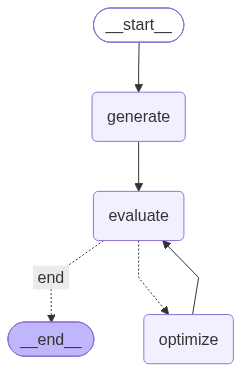

In [96]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())